In [10]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

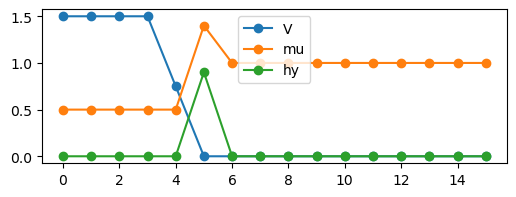

In [11]:
widthS = 5
widthF1 = 1
widthF2 = 10
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [12]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hy=hy)

In [13]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.04066807837272663
Relative error: 40668078372.72663
Average old: 0j
Average: (0.004639628065590131+8.958146276504593e-19j)
F_xplus:
Absolute error: 0.1695065794500939
Relative error: 24315406812.408615
Average old: (0.02666666666666667+0j)
Average: (0.052490800552266514-3.209782012862992e-18j)
F_xmin:
Absolute error: 0.1695065794500936
Relative error: 24315406812.40956
Average old: (0.02666666666666667+0j)
Average: (0.05249080055226685-1.0352636376931993e-17j)
F_yplus:
Absolute error: 0.16885557261970002
Relative error: 68338874347.472534
Average old: (-0.025+0j)
Average: (-0.05295238203941437-1.2242237898478e-16j)
F_ymin:
Absolute error: 0.16885557261969983
Relative error: 68338874347.472275
Average old: (-0.025+0j)
Average: (-0.05295238203941427+1.3187396878544836e-16j)
Fuu_xplus:
Absolute error: 0.014317465897648603
Relative error: 14317465897.648603
Average old: 0j
Average: (1.6007216298103532e-18-0.0024860503223996756j)
Fuu_xmin:
Absolute error: 0.01431746589

In [14]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


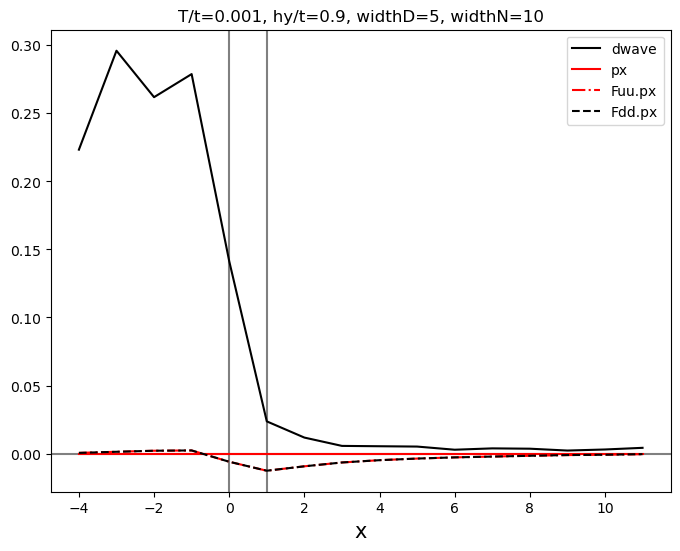

In [15]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )

# axs.set_ylim(None, 0.04)
# axs.set_xlim(-4, 10)
# axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [16]:
F1, Fuu1, Fdd1 = H.get_correlations()

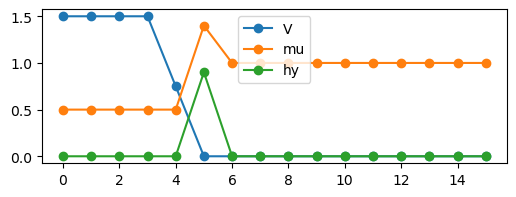

In [17]:
widthS = 5
widthF1 = 1
widthF2 = 10
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [18]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hx=hy)

In [19]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.04066807837272673
Relative error: 40668078372.72672
Average old: 0j
Average: (0.004639628065590183+0j)
F_xplus:
Absolute error: 0.16950657945009304
Relative error: 24315406812.408463
Average old: (0.02666666666666667+0j)
Average: (0.05249080055226649+0j)
F_xmin:
Absolute error: 0.16950657945009293
Relative error: 24315406812.409203
Average old: (0.02666666666666667+0j)
Average: (0.052490800552266674+0j)
F_yplus:
Absolute error: 0.16885557261969958
Relative error: 68338874347.47267
Average old: (-0.025+0j)
Average: (-0.05295238203941425-8.638241444898813e-17j)
F_ymin:
Absolute error: 0.16885557261969958
Relative error: 68338874347.47267
Average old: (-0.025+0j)
Average: (-0.05295238203941425+8.638241444898813e-17j)
Fuu_xplus:
Absolute error: 0.014317465897648731
Relative error: 14317465897.648731
Average old: 0j
Average: (0.0024860503223996795+0j)
Fuu_xmin:
Absolute error: 0.014317465897648497
Relative error: 14317465897.648497
Average old: 0j
Average: (-0.00248605

In [20]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


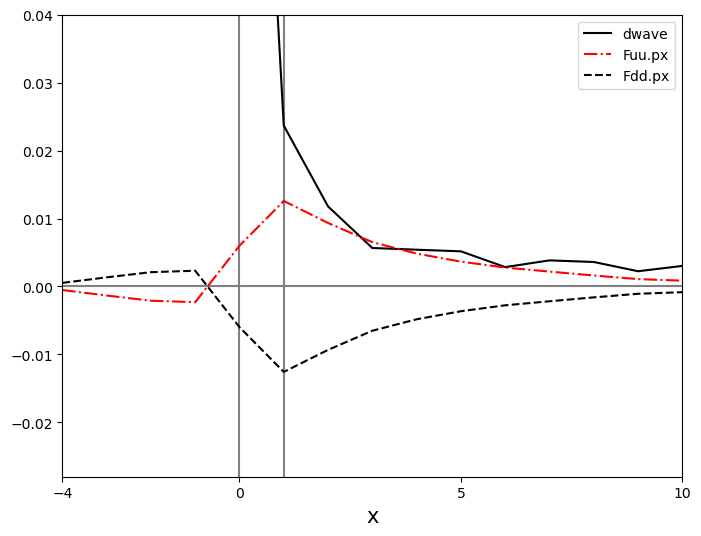

In [21]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.real(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.real(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

axs.set_ylim(None, 0.04)
axs.set_xlim(-4, 10)
axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [22]:
F2, Fuu2, Fdd2 = H.get_correlations()

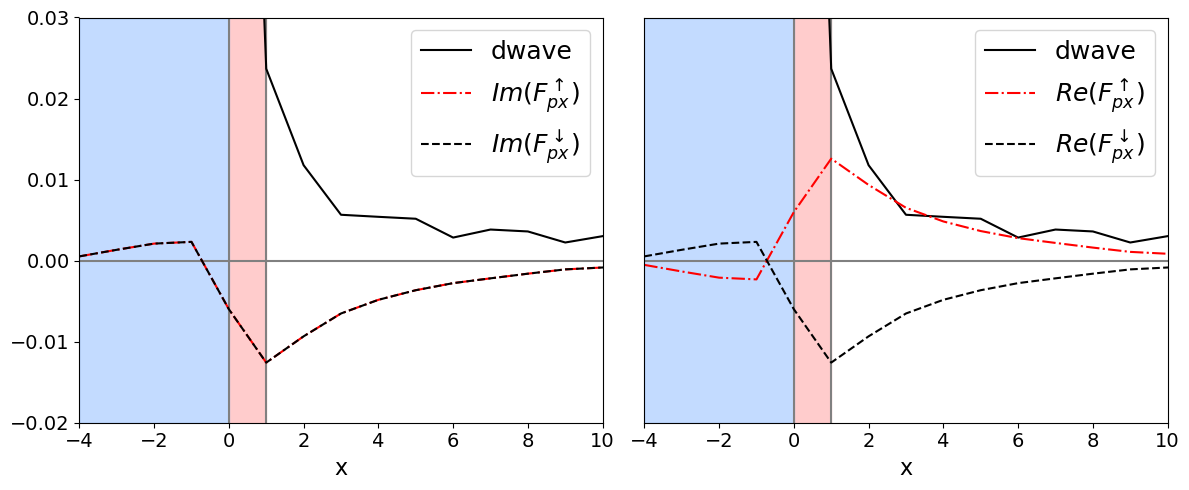

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].axhline(0, color='gray')
axs[0].axvline(0, color='gray')
axs[0].axvline(widthF1, color='gray')

axs[0].plot(x, np.abs(F1.dwave), label=r"dwave", color='black')
axs[0].plot(x, np.imag(Fuu1.px), "-.", label=r"$Im(F^{\uparrow}_{px})$", color='red')
axs[0].plot(x, np.imag(Fdd1.px), "--", label=r"$Im(F^{\downarrow}_{px})$", color='black')

axs[0].set_xlabel("x", fontsize=16)
axs[0].set_ylim(-0.02, 0.03)
axs[0].set_xlim(-4, 10)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].legend(fontsize=18)
axs[0].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[0].axvspan(-4, 0, color='#89B9FF', alpha=0.5)


axs[1].axhline(0, color='gray')
axs[1].axvline(0, color='gray')
axs[1].axvline(widthF1, color='gray')

axs[1].plot(x, np.abs(F2.dwave), label=r"dwave", color='black')
axs[1].plot(x, np.real(Fuu2.px), "-.", label=r"$Re(F^{\uparrow}_{px})$", color='red')
axs[1].plot(x, np.real(Fdd2.px), "--", label=r"$Re(F^{\downarrow}_{px})$", color='black')

axs[1].set_xlabel("x", fontsize=16)
axs[1].set_ylim(-0.02, 0.03)
axs[1].set_xlim(-4, 10)
axs[1].set_yticks([])
axs[1].tick_params(axis='x', labelsize=14)
axs[1].legend(fontsize=18)
axs[1].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[1].axvspan(-4, 0, color='#89B9FF', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/DFN_small.svg", bbox_inches='tight')